In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# Catalog of all objects from all the different combinations (single exposures, deep coadds, etc.)
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/cascades/3.1/LRG/alltiles_LRGzinfo.fits'))
print(len(zbest))

1083682


In [4]:
# Select deep coadds
mask = zbest['subset']=='deep'
print(np.sum(mask))

# Select QSO+LRG tiles
mask &= zbest['TARGETS']=='QSO+LRG'
print(np.sum(mask))

zbest = zbest[mask]

print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

58113
34868
34868
34702


In [5]:
# # Print summary of the tiles
# t = Table()
# t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
# t['efftime'] = 0
# t['n_exp'] = 0
# for index, tileid in enumerate(t['TILEID']):
#     mask = zbest['TILEID']==tileid
#     t['n_exp'][index] = np.max(zbest['COADD_NUMEXP'][mask])
#     t['efftime'][index] = np.max(zbest['EFFTIME_DARK'][mask])
# t

In [6]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))

FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 18686 10684 0.636227442969016
18686


In [7]:
# Ting-Wen's quality cuts
mask = zbest['DELTACHI2']>20
mask &= zbest['Z']<1.4

mask &= zbest['ZWARN']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

Quality cuts 18202 484 0.9740982553783581
18202


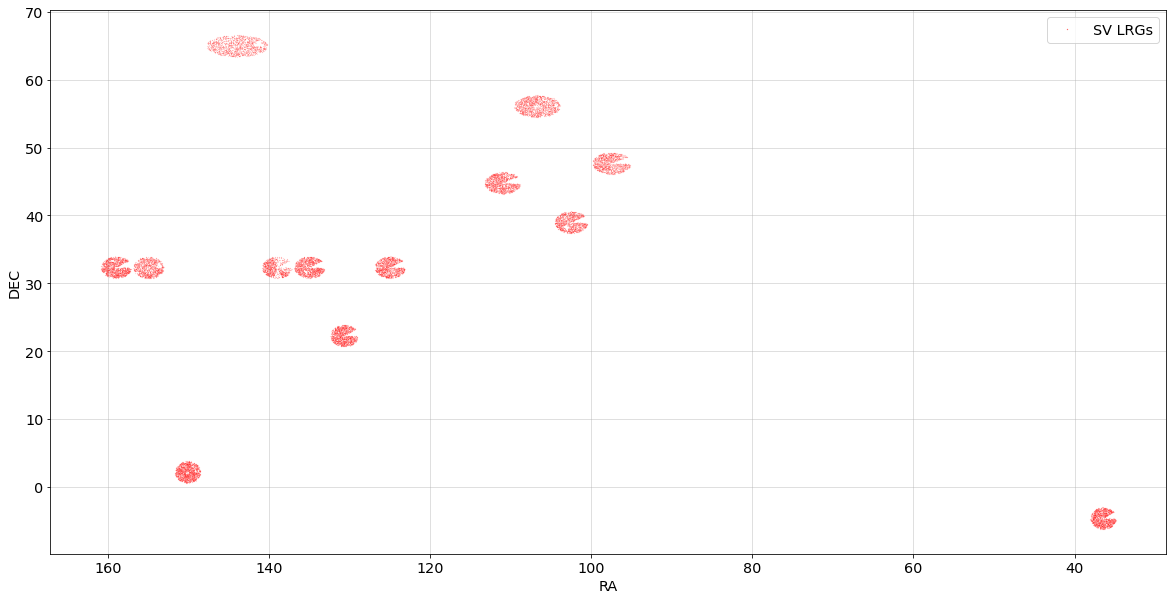

In [8]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

__Add Galactic extinction columns from sweep catalogs (it might take a minute or two)__

In [9]:
ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2']

# Snippets taken from desitarget

from desitarget.targets import encode_targetid

def decode_sweep_name(sweepname):
    sweepname = os.path.basename(sweepname)

    ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
    decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

    if sweepname[9] == 'm':
        decmin *= -1
    if sweepname[17] == 'm':
        decmax *= -1

    return [ramin, ramax, decmin, decmax]

def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

    ramin, ramax, decmin, decmax = radecbox

    # ADM check for some common mistakes.
    if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
        msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
        log.critical(msg)
        raise ValueError(msg)

    ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
          & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

    return ii

# Ignore any possible north/south overlap

sweep_fn_list = []
for field in ['north', 'south']:
    sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
    sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
sweep_fn_list = np.array(sweep_fn_list)

sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
mask = np.array([np.any(is_in_box(zbest, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
print(np.sum(mask))
sweep_fn_list = sweep_fn_list[mask]

ls_stack = []
for sweep_fn in sweep_fn_list:
    ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
    targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
    idx = np.where(np.in1d(targetid, zbest['TARGETID']))[0]
    if len(idx)==0:
        continue
    targetid = targetid[idx]
    ls = Table(fitsio.read(sweep_fn, rows=idx, columns=ls_columns))
    ls['TARGETID'] = targetid
    # if '/south/sweep/' in sweep_fn:
    #     ls['field'] = 'south'
    # else:
    #     ls['field'] = 'north'
    # pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
    # pz = Table(fitsio.read(pz_fn, rows=idx))
    # pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
    # ls = hstack([ls, pz])
    ls_stack.append(ls)
ls = vstack(ls_stack)
print(len(zbest), len(ls))

zbest = join(zbest, ls, keys='TARGETID')

31
18202 18202


In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']/zbest['MW_TRANSMISSION_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']/zbest['MW_TRANSMISSION_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']/zbest['MW_TRANSMISSION_W2'])
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']/zbest['MW_TRANSMISSION_Z'])

In [ ]:
ts_qso

In [11]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

4839
5124
18202

422
422
38


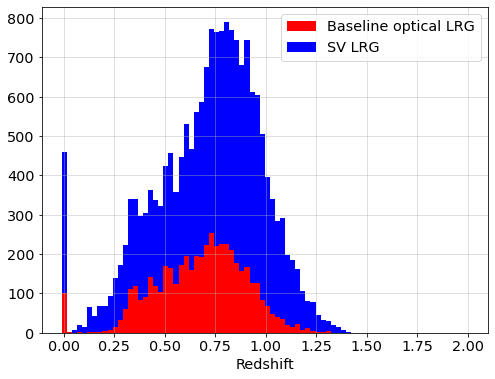

In [13]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=80, range=(-0.01, 2.0), color='red', label='Baseline optical LRG', zorder=1)
plt.hist(zbest['Z'][lrg_sv], bins=80, range=(-0.01, 2.0), color='blue', label='SV LRG', zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

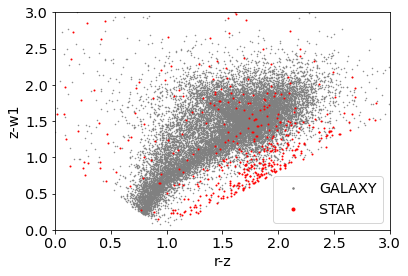

In [23]:
mask_gal = zbest['SPECTYPE']=='GALAXY'
mask_star = zbest['SPECTYPE']=='STAR'
plt.plot((zbest['rmag']-zbest['zmag'])[mask_gal], (zbest['zmag']-zbest['w1mag'])[mask_gal], '.', color='0.5', ms=1, label='GALAXY')
plt.plot((zbest['rmag']-zbest['zmag'])[mask_star],( zbest['zmag']-zbest['w1mag'])[mask_star], 'r.', ms=2, label='STAR')
plt.xlabel('r-z')
plt.ylabel('z-w1')
plt.axis([0, 3, 0, 3])
plt.legend(markerscale=3)
plt.show()

In [24]:
def color_plot_3x2_simple(cat, color_col, idx=None, title=None, vmin=0.2, vmax=1.0, cmap='Dark2_r', ms=0.3, show=True, figaxis=None, colorbar=True, figsize=(18, 20), grid=False):
    '''
    Replace the g-r vs r-z panel with g-r vs r-W1
    '''
    if idx is None:
        idx = np.arange(len(cat))

    if figaxis is None:
        fig, axes = plt.subplots(3, 2, figsize=figsize)
    else:
        fig, axes = figaxis

    # non-stellar cut
    im = axes[0, 0].scatter((cat['rmag']-cat['zmag'])[idx], (cat['zmag']-cat['w1mag'])[idx], 
                c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, 0].set_xlabel('r - z')
    axes[0, 0].set_ylabel('z - W1')
    axes[0, 0].axis([0.2, 2.8, -1, 3])
    if colorbar:
        fig.colorbar(im, ax=axes[0, 0])
    if grid:
        axes[0, 0].grid(alpha=0.5)

    # g-r vs r-W1
    im = axes[0, 1].scatter((cat['rmag']-cat['w1mag'])[idx], (cat['gmag']-cat['rmag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, 1].set_xlabel('r - w1')
    axes[0, 1].set_ylabel('g - r')
    axes[0, 1].axis([-0.2, 4.5, 0, 2.7])
    if colorbar:
        fig.colorbar(im, ax=axes[0, 1])
    if grid:
        axes[0, 1].grid(alpha=0.5)

    # optical sliding cut
    im = axes[1, 0].scatter((cat['zmag'])[idx], (cat['rmag']-cat['zmag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 0].set_xlabel('z')
    axes[1, 0].set_ylabel('r - z')
    axes[1, 0].axis([17, 22., 0.5, 2.6])
    if colorbar:
        fig.colorbar(im, ax=axes[1, 0])
    if grid:
        axes[1, 0].grid(alpha=0.5)
    x = np.linspace(17, 22)

    # IR sliding cut
    im = axes[1, 1].scatter((cat['w1mag'])[idx], (cat['rmag']-cat['w1mag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 1].set_xlabel('W1')
    axes[1, 1].set_ylabel('r - W1')
    axes[1, 1].axis([16.3, 20.2, 0.3, 5.])
    if colorbar:
        fig.colorbar(im, ax=axes[1, 1])
    if grid:
        axes[1, 1].grid(alpha=0.5)
    
    # zfiber vs z
    im = axes[2, 0].scatter((cat['zmag'])[idx], (cat['zfibermag'])[idx], 
             c=cat[color_col][idx], s=ms, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[2, 0].set_xlabel('z')
    axes[2, 0].set_ylabel('zfiber')
    axes[2, 0].axis([17, 22., 18, 23.])
    if colorbar:
        fig.colorbar(im, ax=axes[2, 0])
    if grid:
        axes[2, 0].grid(alpha=0.5)

    axes[2, 1].axis('off')

    if title is not None:
        fig.suptitle(title)
    fig.subplots_adjust(top=0.96)
    
    if show:
        plt.show()
    else:
        return fig, axes

In [31]:
np.unique(zbest['PHOTSYS'], return_counts=True)

(<Column name='PHOTSYS' dtype='str1' length=2>
 N
 S,
 array([9803, 8399]))

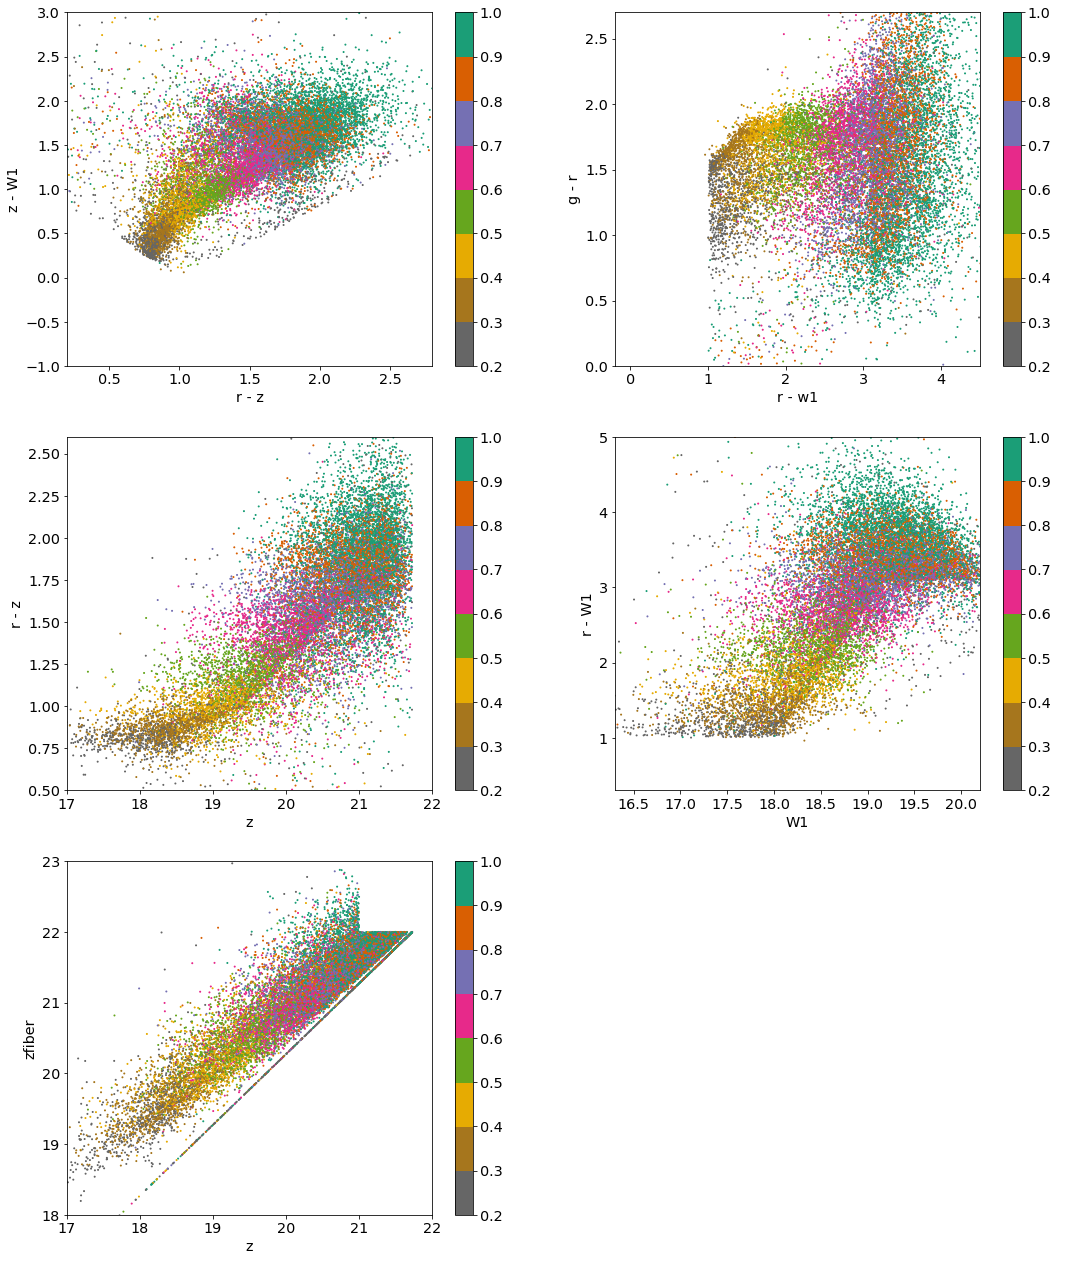

In [27]:
color_plot_3x2_simple(zbest, color_col='Z', ms=1)